{'bert_checkpoint_path': 'bert_checkpoints', 'model': 'ai-forever/ruBert-base'}
bert_checkpoints\bert_latest.ckpt
Program is started
cuda
Parameters is setted
Data is starting to upload
   Unnamed: 0                                               text  label
0           0  mkomov максим вашем письмо мы получили наши со...      0
1           1          мегафон стал владельцем 50 акций евросети      0
2           2  rt fuckkiev evakobb мтс россия прислала жителя...     -1
3           3              видео  реклама со смехом мтс  супер 0      1
4           4  parfenov1960 потому что мтс достало а пчел нен...     -1
{0, 1, 2}
{0, 1, 2}
Epoch 1/2


  0%|          | 0/154 [00:00<?, ?it/s]

C:\Users\ThinkPad T15 Gen1\OneDrive\Desktop\ods_homework\nlp_huawei_new2_task\bert_venv\Lib\site-packages\transformers\tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


  0%|          | 0/360 [00:00<?, ?it/s]

0.7694048285484314
Epoch 2/2


  0%|          | 0/154 [00:00<?, ?it/s]

  0%|          | 0/360 [00:00<?, ?it/s]

0.7763661742210388
The learning procedure has been proceeded.
Inference has been done.
======Stats===========
0.7064264849074976
0.6454740202224094
0.7145709674801368
0.7064264849074976
              precision    recall  f1-score   support

           0       0.81      0.71      0.75       902
           1       0.73      0.72      0.73       972
           2       0.37      0.60      0.46       180

    accuracy                           0.71      2054
   macro avg       0.63      0.68      0.65      2054
weighted avg       0.73      0.71      0.71      2054



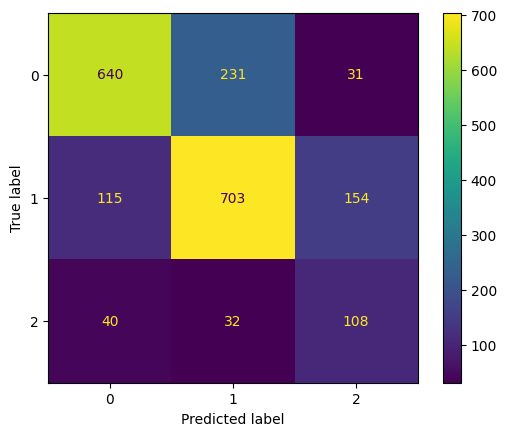

In [3]:
import os
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from dataset import *
from model import *
from trainer import Trainer
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import re
from sklearn.metrics import classification_report
import yaml

config_path = "bert_config.yaml"
with open(config_path, 'r') as f:
    bert_config = yaml.safe_load(f)
print(bert_config)
print(os.path.join(bert_config['bert_checkpoint_path'],"bert_latest.ckpt"))

print("Program is started")
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
PATH = r"models/bert_classifier/"

MAX_LEN = 200
BATCH_SIZE = 16
print("Parameters is setted")

#Fast preprocessing to shortcut main preprocessing step in main.
def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # Удаляем ссылки
    text = re.sub(r'[^\w\s]', '', text)  # Удаляем специальные символы
    text = text.lower()                  # Приводим к нижнему регистру
    return text


print("Data is starting to upload")
train_data = pd.read_csv('../../data/input/tkk_train.csv')
test_data = pd.read_csv('../../data/input/tkk_etalon.csv')

#Used only if preprocess raw data
train_data['text'] = train_data['text'].apply(lambda x: clean_text(x))
test_data['text'] = test_data['text'].apply(lambda x: clean_text(x))
#train_data = pd.read_csv(os.path.join(PATH, "train.csv"))
#test_data = pd.read_csv(os.path.join(PATH, "test.csv"))
print(train_data.head())

#Convert labels
le = LabelEncoder()

train_data.label = le.fit_transform(train_data.label)
test_data.label = le.fit_transform(test_data.label)
#Check labels in input data
print(set(train_data.label))
print(set(test_data.label))

train_split, val_split = train_test_split(train_data, test_size=0.7, random_state=42)

tokenizer = AutoTokenizer.from_pretrained( bert_config['model']
   , truncation=True, do_lower_case=True)

train_dataset = FiveDataset(train_split, tokenizer, MAX_LEN)
val_dataset = FiveDataset(val_split, tokenizer, MAX_LEN)
test_dataset = FiveDataset(test_data, tokenizer, MAX_LEN)

train_params = {"batch_size": BATCH_SIZE,
                "shuffle": True,
                "num_workers": 0
                }

test_params = {"batch_size": BATCH_SIZE,
               "shuffle": False,
               "num_workers": 0
               }

train_dataloader = DataLoader(train_dataset, **train_params)
val_dataloader = DataLoader(val_dataset, **test_params)
test_dataloader = DataLoader(test_dataset, **test_params)

config = {
    "num_classes": 3,
    "dropout_rate": 0.1
}

model = ModelForClassification(
    bert_config['model'],
    config=config
)

trainer_config = {
    "lr": 5e-5,
    "n_epochs": 2,
    "weight_decay": 0.001,
    "batch_size": BATCH_SIZE,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}

t = Trainer(trainer_config)

t.fit(
    model,
    train_dataloader,
    val_dataloader
)
print("The learning procedure has been proceeded.")
#Save checkpoint
t.save(os.path.join(bert_config['bert_checkpoint_path'],"bert_latest.ckpt"))
#t = Trainer.load("baseline_model.ckpt")

predictions = t.predict(test_dataloader)
print("Inference has been done.")
ground_true = test_data['label'].tolist()

#Print results on test data.
print("======Stats===========")
print(f1_score(ground_true, predictions, average='micro'))
print(f1_score(ground_true, predictions, average='macro'))
print(f1_score(ground_true, predictions, average='weighted'))
print(accuracy_score(ground_true, predictions))
print("======================")
print(classification_report(ground_true, predictions))
print("======================")
# pred_labels = le.inverse_transform(preds)
cm = confusion_matrix(ground_true, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()